<a href="https://colab.research.google.com/github/Nandhithavijay/pradhi/blob/main/Decisiontree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.model_selection import train_test_split
from sklearn import metrics
from io import StringIO
from IPython.display import Image
import pydotplus

In [9]:
col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin',
             'bmi', 'pedigree', 'age', 'label']

In [10]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

In [11]:
pima = pd.read_csv(url, header=None, names=col_names)

In [12]:
print(pima.head())

   pregnant  glucose  bp  skin  insulin   bmi  pedigree  age  label
0         6      148  72    35        0  33.6     0.627   50      1
1         1       85  66    29        0  26.6     0.351   31      0
2         8      183  64     0        0  23.3     0.672   32      1
3         1       89  66    23       94  28.1     0.167   21      0
4         0      137  40    35      168  43.1     2.288   33      1


In [13]:
feature_cols = ['pregnant', 'insulin', 'bmi', 'age',
                'glucose', 'bp', 'pedigree']

In [14]:
X = pima[feature_cols]
y = pima.label

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

In [16]:
clf = DecisionTreeClassifier()

In [17]:
clf = clf.fit(X_train, y_train)

In [18]:
y_pred = clf.predict(X_test)

In [19]:
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.6883116883116883


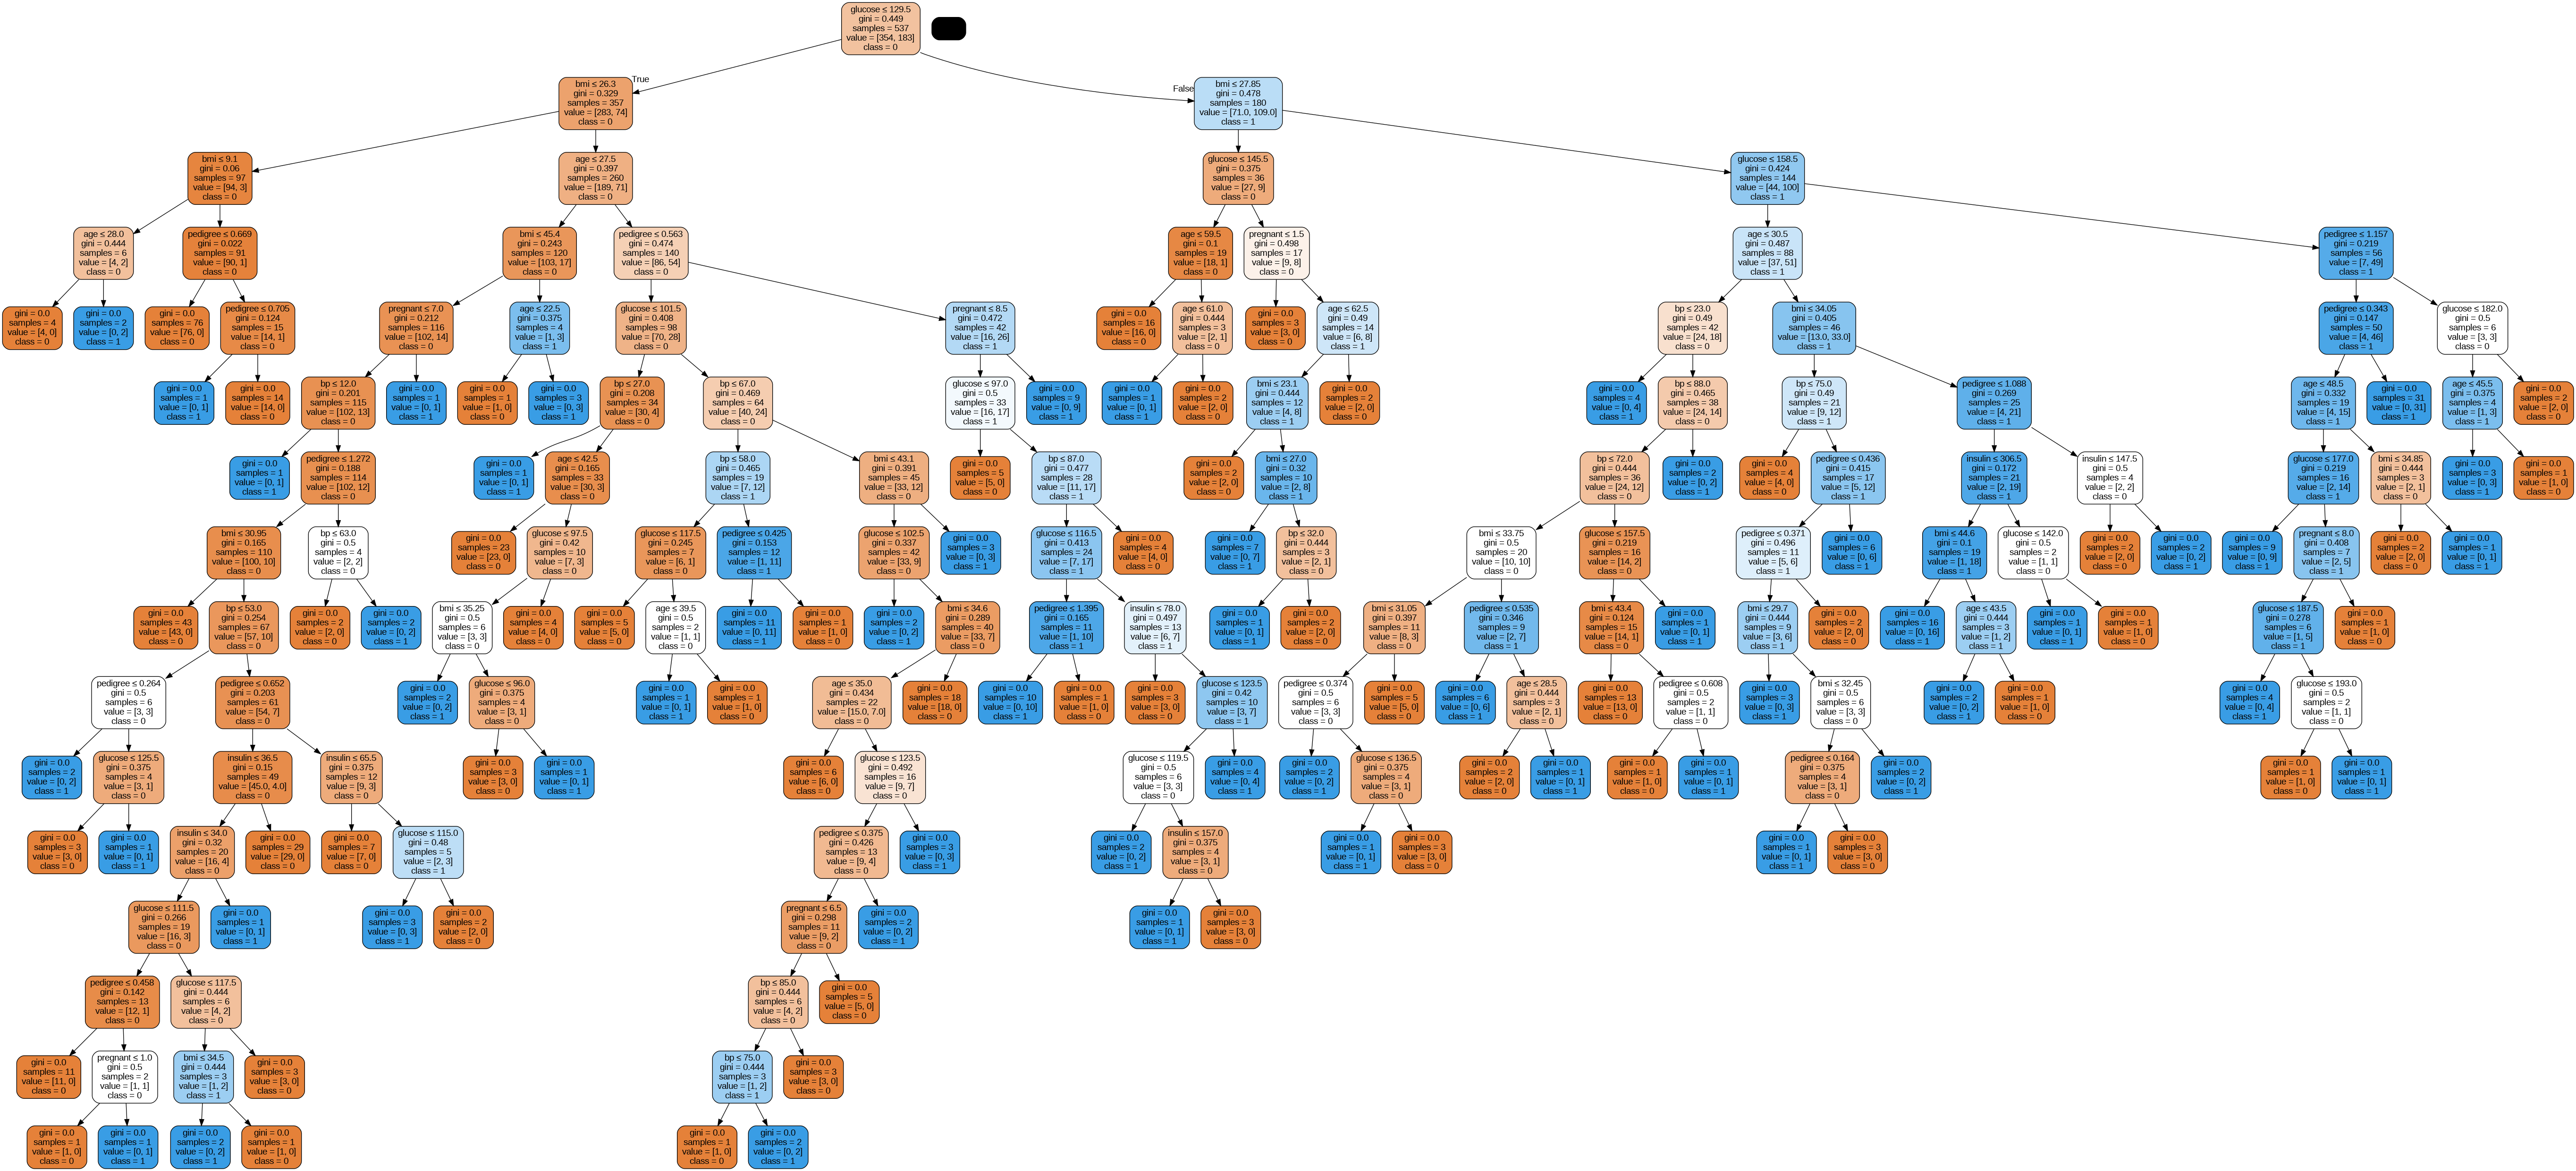

In [20]:
dot_data = StringIO()
export_graphviz(clf, out_file=dot_data,
                filled=True, rounded=True,
                special_characters=True,
                feature_names=feature_cols,
                class_names=['0', '1'])
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png('diabetes.png')
Image(graph.create_png())